In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU ĐIỂM
# Đảm bảo file "diem_goc.xlsx" nằm cùng thư mục với file sổ tay này của bạn
file_path = "diem_goc.xlsx"
df = pd.read_excel(file_path, header=None)

mssv_row = df.iloc[1, 3:].values
name_row = df.iloc[2, 3:].values

student_profiles = []
for idx in range(len(mssv_row)):
    col_idx = 3 + idx
    m_id = mssv_row[idx]
    m_name = name_row[idx]

    if pd.isna(m_id) and pd.isna(m_name):
        continue

    raw_scores = df.iloc[4:, col_idx].values
    cleaned_scores = pd.to_numeric(raw_scores, errors='coerce')
    valid_scores = cleaned_scores[~np.isnan(cleaned_scores)]

    if len(valid_scores) > 0:
        student_profiles.append({
            "MSSV": str(m_id).strip(),
            "Tên Sinh Viên": str(m_name).strip(),
            "Số môn đã học": len(valid_scores),
            "GPA_He_4": round(np.mean(valid_scores), 2)
        })

df_hoc_luc = pd.DataFrame(student_profiles)

# 2. CHẠY K-MEANS PHÂN LOẠI HỌC LỰC (3 CỤM)
X_rank = df_hoc_luc[['GPA_He_4']].values
kmeans_rank = KMeans(n_clusters=3, random_state=42, n_init=10)
df_hoc_luc['Rank_Cluster'] = kmeans_rank.fit_predict(X_rank)

# Định vị tâm cụm toán học để gán nhãn chính xác từ thấp đến cao
centers_rank = kmeans_rank.cluster_centers_.flatten()
sorted_rank_idx = np.argsort(centers_rank)

label_rank_mapping = {
    sorted_rank_idx[0]: "Trung bình (K-Means)",
    sorted_rank_idx[1]: "Khá (K-Means)",
    sorted_rank_idx[2]: "Giỏi/Xuất sắc (K-Means)"
}
df_hoc_luc['Phân Loại Học Lực (K-Means)'] = df_hoc_luc['Rank_Cluster'].map(label_rank_mapping)

# 3. DỌN DẸP SẮP XẾP VÀ XUẤT FILE EXCEL RIÊNG CỦA BÀI TOÁN HỌC LỰC
df_hoc_luc.drop(columns=['Rank_Cluster'], inplace=True)
df_hoc_luc = df_hoc_luc.sort_values(by="GPA_He_4", ascending=False)
df_hoc_luc.insert(0, 'STT', range(1, 1 + len(df_hoc_luc)))

output_hoc_luc = "Ket_Qua_Phan_Lop_Hoc_Luc_KMeans.xlsx"
df_hoc_luc.to_excel(output_hoc_luc, index=False)

print(f"✔️ Đã xử lý xong toán học và xuất file Excel: '{output_hoc_luc}'")

✔️ Đã xử lý xong toán học và xuất file Excel: 'Ket_Qua_Phan_Lop_Hoc_Luc_KMeans.xlsx'


📊 THỐNG KÊ PHÂN LỚP HỌC LỰC 3 CỤM TỰ ĐỘNG BẰNG K-MEANS:
 - Giỏi/Xuất sắc (K-Means)  : 21 sinh viên
 - Khá (K-Means)            : 25 sinh viên
 - Trung bình (K-Means)     : 20 sinh viên


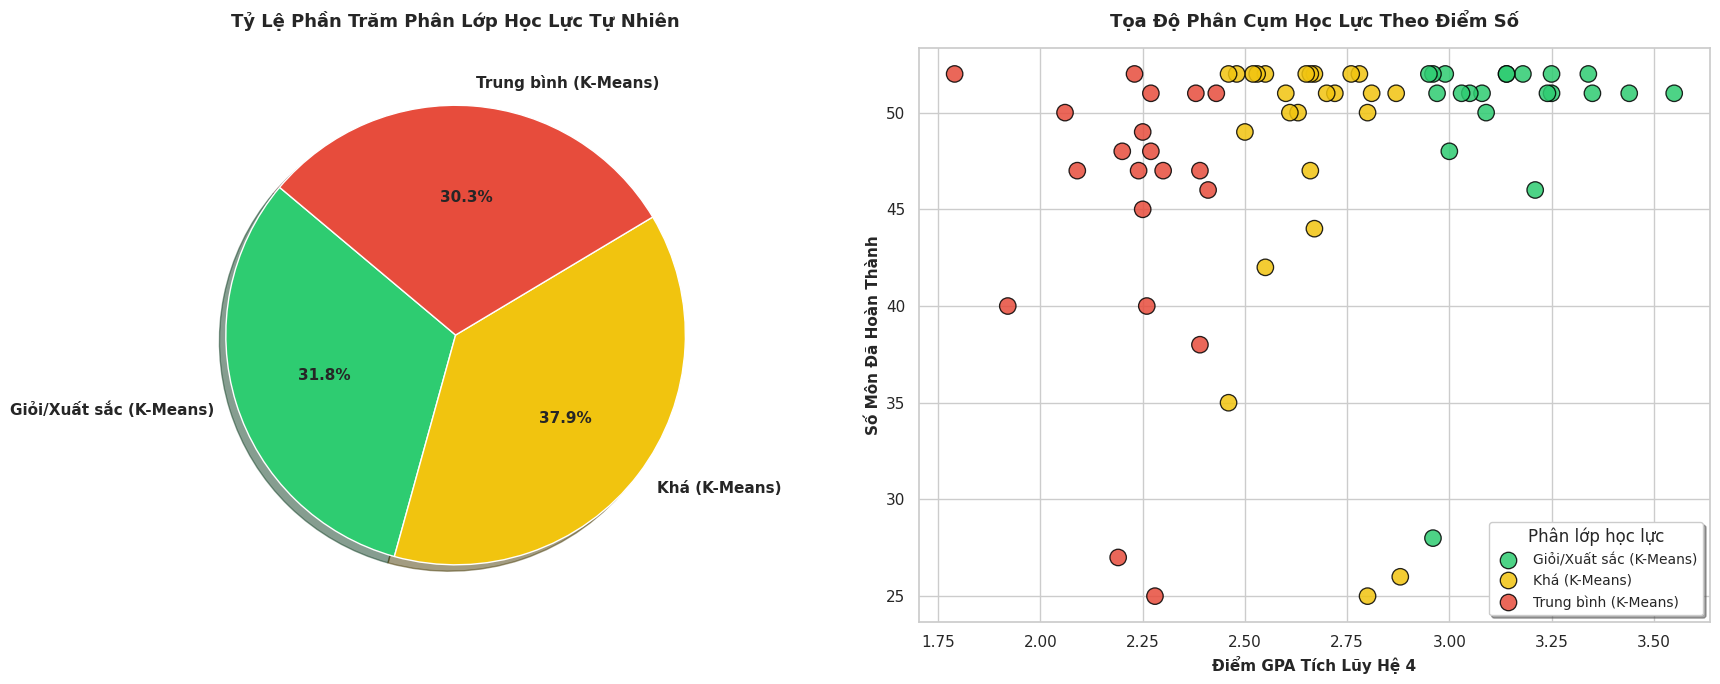

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. IN KẾT QUẢ THỐNG KÊ DẠNG CHỮ RA TERMINAL
# ==============================================================================
print("=" * 70)
print("📊 THỐNG KÊ PHÂN LỚP HỌC LỰC 3 CỤM TỰ ĐỘNG BẰNG K-MEANS:")
print("=" * 70)
stats_rank = df_hoc_luc['Phân Loại Học Lực (K-Means)'].value_counts()
rank_order = ["Giỏi/Xuất sắc (K-Means)", "Khá (K-Means)", "Trung bình (K-Means)"]
for nhom in rank_order:
    print(f" - {nhom:<25}: {stats_rank.get(nhom, 0):>2} sinh viên")
print("=" * 70)

# ==============================================================================
# 2. VẼ BỘ ĐÔI BIỂU ĐỒ TRỰC QUAN HÓA (BIỂU ĐỒ TRÒN & BIỂU ĐỒ CHẤM)
# ==============================================================================
sns.set_theme(style="whitegrid")

# Tạo một khung hình chứa 2 biểu đồ nằm song song (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bảng màu nhất quán cho cả 2 biểu đồ (Xanh lá - Vàng - Đỏ)
rank_colors_dict = {
    "Giỏi/Xuất sắc (K-Means)": "#2ecc71",
    "Khá (K-Means)": "#f1c40f",
    "Trung bình (K-Means)": "#e74c3c"
}

# --- PHẦN A: VẼ BIỂU ĐỒ TRÒN (BÊN TRÁI) ---
# Lấy số lượng và nhãn theo đúng thứ tự sắp xếp
pie_data = [stats_rank.get(nhom, 0) for nhom in rank_order]
pie_colors = [rank_colors_dict[nhom] for nhom in rank_order]

axes[0].pie(
    pie_data,
    labels=rank_order,
    colors=pie_colors,
    autopct='%1.1f%%',          # Hiển thị tỷ lệ phần trăm (ví dụ: 35.2%)
    startangle=140,             # Góc xoay bắt đầu để biểu đồ cân đối
    shadow=True,                # Tạo hiệu ứng đổ bóng cho đẹp mắt
    textprops={'fontsize': 11, 'fontweight': 'bold'} # Định dạng chữ hiển thị
)
axes[0].set_title("Tỷ Lệ Phần Trăm Phân Lớp Học Lực Tự Nhiên", fontsize=13, fontweight='bold', pad=15)


# --- PHẦN B: VẼ BIỂU ĐỒ CHẤM SCATTER PLOT (BÊN PHẢI) ---
sns.scatterplot(
    ax=axes[1],
    data=df_hoc_luc, x="GPA_He_4", y="Số môn đã học",
    hue="Phân Loại Học Lực (K-Means)", hue_order=rank_order,
    s=140, alpha=0.85, edgecolor="black", palette=rank_colors_dict
)
axes[1].set_title("Tọa Độ Phân Cụm Học Lực Theo Điểm Số", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Điểm GPA Tích Lũy Hệ 4", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Số Môn Đã Hoàn Thành", fontsize=11, fontweight='bold')
axes[1].legend(title="Phân lớp học lực", shadow=True, fontsize=10)


# Hoàn thiện bố cục và lưu ảnh
plt.tight_layout()
plt.savefig("bieu_do_tron_va_cham_hoc_luc.png", dpi=300)
plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU ĐẦU VÀO
# Đảm bảo file "diem_goc.xlsx" nằm cùng thư mục với file sổ tay mới này
file_path = "diem_goc.xlsx"
df = pd.read_excel(file_path, header=None)

mssv_row = df.iloc[1, 3:].values
name_row = df.iloc[2, 3:].values

student_profiles = []
for idx in range(len(mssv_row)):
    col_idx = 3 + idx
    m_id = mssv_row[idx]
    m_name = name_row[idx]

    if pd.isna(m_id) and pd.isna(m_name):
        continue

    raw_scores = df.iloc[4:, col_idx].values
    cleaned_scores = pd.to_numeric(raw_scores, errors='coerce')
    valid_scores = cleaned_scores[~np.isnan(cleaned_scores)]

    if len(valid_scores) > 0:
        student_profiles.append({
            "MSSV": str(m_id).strip(),
            "Tên Sinh Viên": str(m_name).strip(),
            "Số môn đã học": len(valid_scores),
            "GPA_He_4": round(np.mean(valid_scores), 2)
        })

df_tien_do = pd.DataFrame(student_profiles)

# 2. CHẠY K-MEANS PHÂN LOẠI TIẾN ĐỘ TÍCH LŨY MÔN HỌC (3 CỤM)
X_progress = df_tien_do[['Số môn đã học']].values
kmeans_prog = KMeans(n_clusters=3, random_state=42, n_init=10)
df_tien_do['Prog_Cluster'] = kmeans_prog.fit_predict(X_progress)

# Định vị tâm cụm toán học để gán nhãn chính xác theo số môn từ ít đến nhiều
centers_prog = kmeans_prog.cluster_centers_.flatten()
sorted_prog_idx = np.argsort(centers_prog)

label_prog_mapping = {
    sorted_prog_idx[0]: "Tiến Độ Chậm (Nguy cơ nợ môn)",
    sorted_prog_idx[1]: "Tiến Độ Bình Thường (Đúng lộ trình)",
    sorted_prog_idx[2]: "Tiến Độ Nhanh (Học vượt)"
}
df_tien_do['Tiến Độ Học Tập (K-Means)'] = df_tien_do['Prog_Cluster'].map(label_prog_mapping)

# 3. DỌN DẸP SẮP XẾP VÀ XUẤT FILE EXCEL RIÊNG CỦA BÀI TOÁN B
df_tien_do.drop(columns=['Prog_Cluster'], inplace=True)
df_tien_do = df_tien_do.sort_values(by="Số môn đã học", ascending=False)
df_tien_do.insert(0, 'STT', range(1, 1 + len(df_tien_do)))

output_tien_do = "Ket_Qua_Phan_Lop_Tien_Do_KMeans.xlsx"
df_tien_do.to_excel(output_tien_do, index=False)

print(f"✔️ Đã xử lý xong toán học tiến độ và xuất file Excel: '{output_tien_do}'")

✔️ Đã xử lý xong toán học tiến độ và xuất file Excel: 'Ket_Qua_Phan_Lop_Tien_Do_KMeans.xlsx'


⏳ THỐNG KÊ PHÂN LỚP TIẾN ĐỘ TÍCH LŨY MÔN HỌC BẰNG K-MEANS:
 - Tiến Độ Nhanh (Học vượt)           : 54 sinh viên
 - Tiến Độ Bình Thường (Đúng lộ trình):  7 sinh viên
 - Tiến Độ Chậm (Nguy cơ nợ môn)      :  5 sinh viên


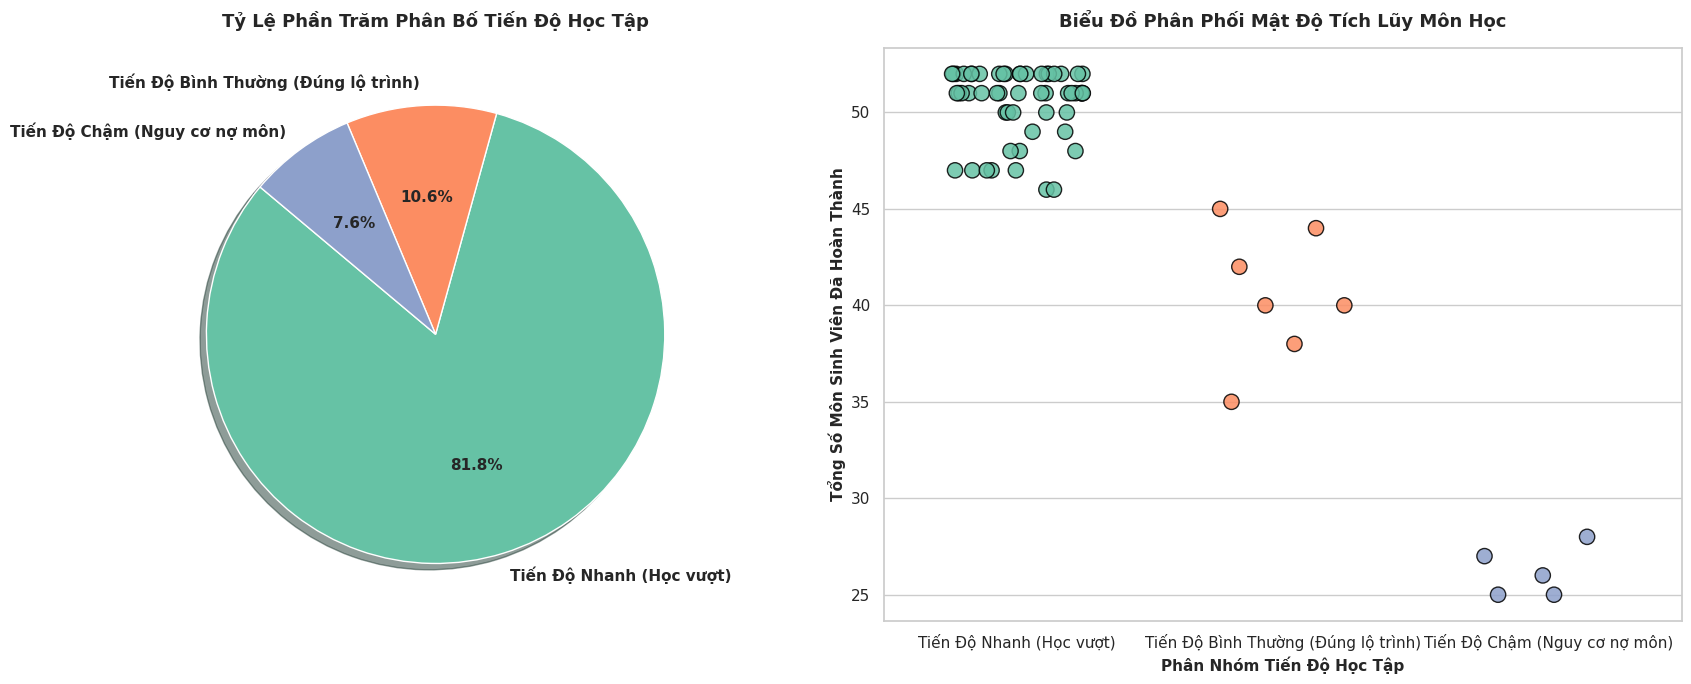

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. IN KẾT QUẢ THỐNG KÊ DẠNG CHỮ
# ==============================================================================
print("=" * 70)
print("⏳ THỐNG KÊ PHÂN LỚP TIẾN ĐỘ TÍCH LŨY MÔN HỌC BẰNG K-MEANS:")
print("=" * 70)
stats_prog = df_tien_do['Tiến Độ Học Tập (K-Means)'].value_counts()
prog_order = ["Tiến Độ Nhanh (Học vượt)", "Tiến Độ Bình Thường (Đúng lộ trình)", "Tiến Độ Chậm (Nguy cơ nợ môn)"]
for nhom in prog_order:
    print(f" - {nhom:<35}: {stats_prog.get(nhom, 0):>2} sinh viên")
print("=" * 70)

# ==============================================================================
# 2. VẼ BỘ ĐÔI BIỂU ĐỒ TRỰC QUAN HÓA (TRÒN & MẬT ĐỘ)
# ==============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bảng màu đại diện cho các nhóm tiến độ (Xanh lam - Ngọc - Cam đậm)
prog_colors_dict = {
    "Tiến Độ Nhanh (Học vượt)": "#66c2a5",
    "Tiến Độ Bình Thường (Đúng lộ trình)": "#fc8d62",
    "Tiến Độ Chậm (Nguy cơ nợ môn)": "#8da0cb"
}

# --- PHẦN A: VẼ BIỂU ĐỒ TRÒN TIẾN ĐỘ (BÊN TRÁI) ---
pie_data = [stats_prog.get(nhom, 0) for nhom in prog_order]
pie_colors = [prog_colors_dict[nhom] for nhom in prog_order]

axes[0].pie(
    pie_data,
    labels=prog_order,
    colors=pie_colors,
    autopct='%1.1f%%',          # Hiện % chi tiết
    startangle=140,
    shadow=True,                # Hiệu ứng đổ bóng 3D nhẹ
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title("Tỷ Lệ Phần Trăm Phân Bố Tiến Độ Học Tập", fontsize=13, fontweight='bold', pad=15)


# --- PHẦN B: VẼ BIỂU ĐỒ MẬT ĐỘ STRIPPLOT (BÊN PHẢI) ---
sns.stripplot(
    ax=axes[1],
    data=df_tien_do, x="Tiến Độ Học Tập (K-Means)", y="Số môn đã học",
    hue="Tiến Độ Học Tập (K-Means)", order=prog_order, jitter=0.25, size=11,
    alpha=0.85, edgecolor="black", linewidth=1, palette=prog_colors_dict, legend=False
)
axes[1].set_title("Biểu Đồ Phân Phối Mật Độ Tích Lũy Môn Học", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Phân Nhóm Tiến Độ Học Tập", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Tổng Số Môn Sinh Viên Đã Hoàn Thành", fontsize=11, fontweight='bold')

plt.tight_layout()

# Tự động lưu file ảnh kết quả của bài toán B ra máy tính
plt.savefig("bieu_do_tron_va_mat_do_tien_do.png", dpi=300)
plt.show()